# SRAG Mossoro - Analise e Previsao (Notebook Unico)

Este notebook cobre o fluxo fim a fim: carga de dados, analise epidemiologica e previsao de curto prazo.

In [1]:
from __future__ import annotations

from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    curr = (start or Path.cwd()).resolve()
    for p in [curr, *curr.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError('Nao foi possivel localizar a raiz do repositorio (pyproject.toml).')

ROOT = find_repo_root()
DB_PATH = ROOT / 'data' / 'srag_mossoro.db'
CSV_FALLBACK = ROOT / 'data' / 'srag_mossoro_secure.csv'

WEEKS_TO_PREDICT = 4
HOLDOUT_WEEKS = 4

print(f'ROOT: {ROOT}')
print(f'DB_PATH: {DB_PATH}')
print(f'CSV_FALLBACK: {CSV_FALLBACK}')

ROOT: /home/alerrandro/Desktop/SRAG
DB_PATH: /home/alerrandro/Desktop/SRAG/data/srag_mossoro.db
CSV_FALLBACK: /home/alerrandro/Desktop/SRAG/data/srag_mossoro_secure.csv


In [3]:
import sys

SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from srag.data.analytics import (
    compute_age_groups,
    compute_severity_metrics,
    compute_time_series,
    compute_virus_distribution,
)
from srag.models.forecasting import predict_next_weeks

In [4]:
def load_cases_dataframe(db_path: Path, csv_fallback: Path) -> pd.DataFrame:
    if db_path.exists():
        with sqlite3.connect(db_path) as conn:
            df = pd.read_sql_query('SELECT * FROM casos_srag', conn)
        date_cols = ['dt_notific', 'dt_sin_pri']
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce').dt.date
        return df

    if csv_fallback.exists():
        df = pd.read_csv(csv_fallback)
        for c in ['dt_notific', 'dt_sin_pri']:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce').dt.date
        return df

    raise FileNotFoundError(
        f'Dados nao encontrados. Gere o banco em {db_path} ou um CSV em {csv_fallback}.'
    )

In [5]:
df = load_cases_dataframe(DB_PATH, CSV_FALLBACK)

print(f'Total de registros: {len(df)}')
print('Colunas:', ', '.join(df.columns))
df.head()

Total de registros: 66
Colunas: unique_hash, dt_notific, id_municip, id_mn_resi, dt_sin_pri, nu_idade_n, cs_sexo, classi_fin, evolucao, uti, hospital, idade_anos


,unique_hash,dt_notific,id_municip,id_mn_resi,dt_sin_pri,nu_idade_n,cs_sexo,classi_fin,evolucao,uti,hospital,idade_anos
0,cba1c0b5e33a717fb1f883857ee1ec8c,2019-02-14,MOSSORO,SANTANA DO MATOS,2019-02-12,22,F,4.0,1.0,1.0,1,None
1,86462ac725399bbe88cedc4c46042e76,2019-02-24,MOSSORO,ITAJA,2019-02-17,6,F,2.0,1.0,2.0,1,None
2,d7b39b48efb479ef2b23d44b188c05f6,2019-03-01,MOSSORO,MOSSORO,2019-02-24,9,F,2.0,1.0,1.0,1,None
3,0ed2ef642b8415b3f15a09da63134cd0,2019-03-08,MOSSORO,UPANEMA,2019-03-04,20,F,NaN,NaN,1.0,1,None
4,e95d78e171cecb8e26f9f520d1e50038,2019-03-11,MOSSORO,MOSSORO,2019-03-06,3,M,2.0,2.0,1.0,1,None


## 1) Qualidade e consistencia dos dados

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15).to_frame('missing_pct_top15')

,missing_pct_top15
idade_anos,100.000000
uti,4.545455
evolucao,3.030303
classi_fin,3.030303
id_mn_resi,0.000000
id_municip,0.000000
dt_notific,0.000000
unique_hash,0.000000
cs_sexo,0.000000
nu_idade_n,0.000000


In [7]:
if 'dt_sin_pri' in df.columns:
    invalid_dates = df['dt_sin_pri'].isna().sum()
    print(f'Datas de inicio de sintomas invalidas/ausentes: {invalid_dates}')

if 'idade_anos' in df.columns:
    invalid_age = (pd.to_numeric(df['idade_anos'], errors='coerce') < 0).sum()
    print(f'Idades negativas: {invalid_age}')

Datas de inicio de sintomas invalidas/ausentes: 0
Idades negativas: 0


## 2) Analise epidemiologica

In [8]:
metrics = compute_severity_metrics(df.copy())
pd.DataFrame([metrics])

,uti_rate,death_rate,total_cases
0,62.12,30.3,66


In [9]:
virus_df = compute_virus_distribution(df.copy())
virus_df = virus_df.sort_values('count', ascending=False)
virus_df

,virus,count
2,Não Especificada,41
3,Outros Vírus,15
1,Influenza,8
0,Em Investigação,2


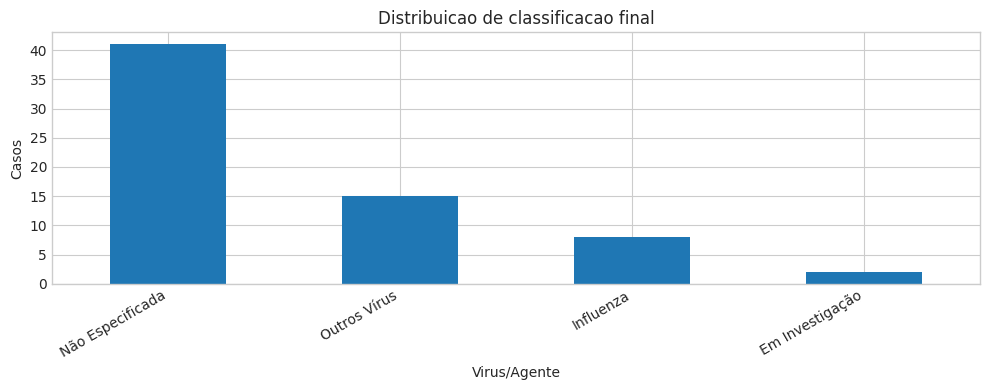

In [10]:
if not virus_df.empty:
    ax = virus_df.plot(kind='bar', x='virus', y='count', figsize=(10, 4), legend=False)
    ax.set_title('Distribuicao de classificacao final')
    ax.set_xlabel('Virus/Agente')
    ax.set_ylabel('Casos')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
age_df = compute_age_groups(df.copy())
age_df = age_df.sort_values('count', ascending=False)
age_df

,faixa_etaria,count


In [12]:
if not age_df.empty:
    ax = age_df.plot(kind='bar', x='faixa_etaria', y='count', figsize=(10, 4), legend=False, color='#386cb0')
    ax.set_title('Casos por faixa etaria')
    ax.set_xlabel('Faixa etaria')
    ax.set_ylabel('Casos')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [13]:
ts_df = compute_time_series(df.copy())
ts_df.tail(12)

,epi_week,total_cases
15,2019-22,4
16,2019-23,5
17,2019-24,5
18,2019-26,2
19,2019-28,1
20,2019-29,2
21,2019-31,2
22,2019-32,1
23,2019-33,1
24,2019-34,1


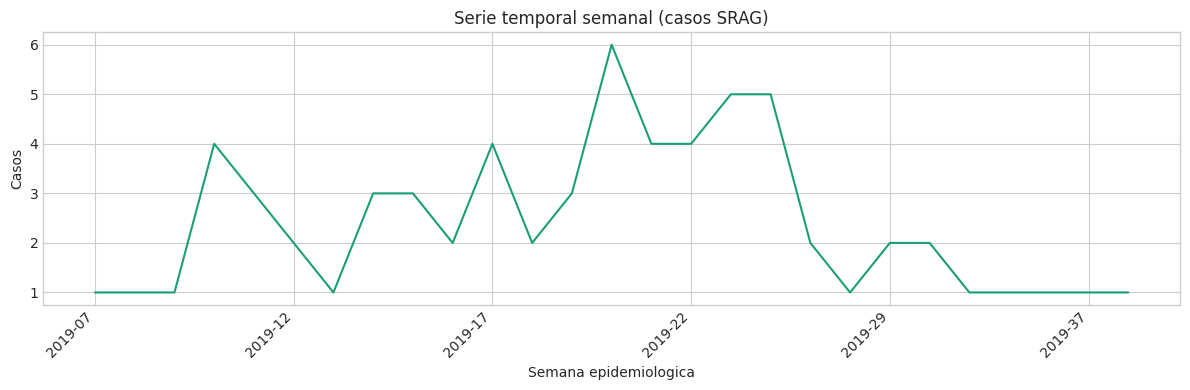

In [14]:
if not ts_df.empty:
    ax = ts_df.plot(x='epi_week', y='total_cases', figsize=(12, 4), legend=False, color='#1b9e77')
    ax.set_title('Serie temporal semanal (casos SRAG)')
    ax.set_xlabel('Semana epidemiologica')
    ax.set_ylabel('Casos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3) Previsao de curto prazo

In [15]:
forecast_result = predict_next_weeks(ts_df.copy(), weeks_to_predict=WEEKS_TO_PREDICT)

history_df = pd.DataFrame(forecast_result.get('history', []))
forecast_df = pd.DataFrame(forecast_result.get('forecast', []))

print('status:', forecast_result.get('status'))
print('model_type:', forecast_result.get('model_type'))
forecast_df

status: success
model_type: linear_trend_smoothed


,epi_week,predicted_cases,is_forecast
0,2019-40,0.7,True
1,2019-41,0.6,True
2,2019-42,0.5,True
3,2019-43,0.4,True


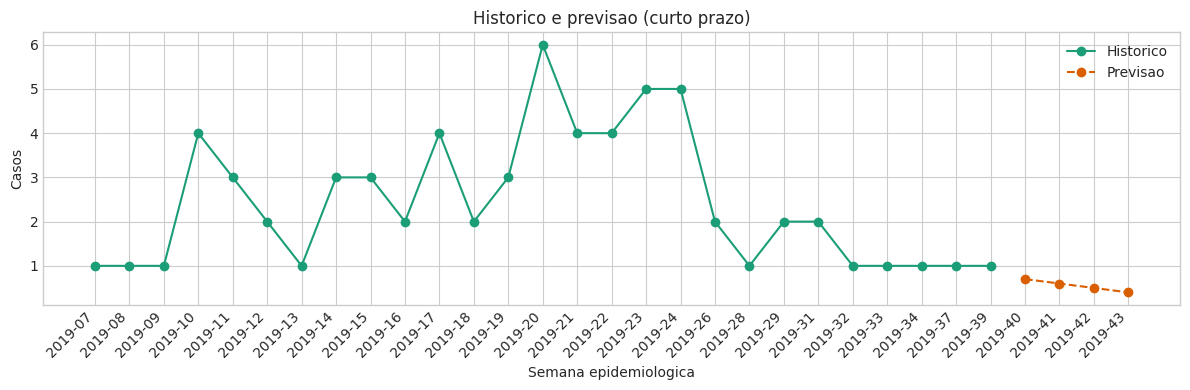

In [16]:
if not history_df.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(history_df['epi_week'], history_df['total_cases'], marker='o', label='Historico', color='#1b9e77')

    if not forecast_df.empty:
        plt.plot(forecast_df['epi_week'], forecast_df['predicted_cases'], marker='o', linestyle='--', label='Previsao', color='#d95f02')

    plt.title('Historico e previsao (curto prazo)')
    plt.xlabel('Semana epidemiologica')
    plt.ylabel('Casos')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4) Validacao simples (holdout)

In [17]:
def evaluate_holdout(ts: pd.DataFrame, holdout_weeks: int = 4) -> pd.DataFrame:
    if len(ts) < max(8, holdout_weeks + 4):
        return pd.DataFrame()

    train = ts.iloc[:-holdout_weeks].copy()
    test = ts.iloc[-holdout_weeks:].copy()

    pred = predict_next_weeks(train, weeks_to_predict=holdout_weeks)
    pred_df = pd.DataFrame(pred.get('forecast', []))
    if pred_df.empty:
        return pd.DataFrame()

    out = test[['epi_week', 'total_cases']].reset_index(drop=True).merge(
        pred_df[['epi_week', 'predicted_cases']], on='epi_week', how='left'
    )
    return out

eval_df = evaluate_holdout(ts_df, holdout_weeks=HOLDOUT_WEEKS)
eval_df

,epi_week,total_cases,predicted_cases
0,2019-33,1,0.5
1,2019-34,1,0.0
2,2019-37,1,NaN
3,2019-39,1,NaN


In [18]:
if not eval_df.empty and eval_df['predicted_cases'].notna().all():
    y_true = eval_df['total_cases'].to_numpy()
    y_pred = eval_df['predicted_cases'].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
else:
    print('Nao foi possivel calcular metricas de holdout (dados insuficientes ou semanas sem alinhamento).')

Nao foi possivel calcular metricas de holdout (dados insuficientes ou semanas sem alinhamento).


## 5) Conclusoes operacionais

Preencha ao final da execucao:

- Tendencia atual (alta, queda, estabilidade): ...
- Faixas etarias prioritarias: ...
- Classificacao viral dominante: ...
- Recomendacoes para vigilancia (curto prazo): ...